<h1 align='center'>Country-Wise Netflix Content Analysis   </h1>

### Import Already Cleaned Dataset

In [1]:
import pandas as pd
df = pd.read_csv(f'E:\internship\Auspify\cleaned_netflix_dataset.csv')
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90,Documentaries
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125,"Dramas, Independent Movies, International Movies"


### Extract and Verify Country Data

In [2]:
country_data = df["country"]

print("Total country records:", len(country_data))
print("Unique countries:", country_data.nunique())
print("Missing country values:", country_data.isna().sum())

Total country records: 8790
Unique countries: 86
Missing country values: 0


### Content Count by Country

In [3]:
country_content_count = (
    df["country"]
    .value_counts()
    .reset_index()
)

country_content_count.columns = ["Country", "Content Count"]

print(country_content_count)

           Country  Content Count
0    United States           3240
1            India           1057
2   United Kingdom            638
3         Pakistan            421
4        Not Given            287
..             ...            ...
81      Luxembourg              1
82         Senegal              1
83         Belarus              1
84     Puerto Rico              1
85          Cyprus              1

[86 rows x 2 columns]


### Top 10 countries by content count

In [4]:
top_countries = country_content_count.head(10)
print(top_countries.to_string(index=False))

       Country  Content Count
 United States           3240
         India           1057
United Kingdom            638
      Pakistan            421
     Not Given            287
        Canada            271
         Japan            259
   South Korea            214
        France            213
         Spain            182


### Visualization

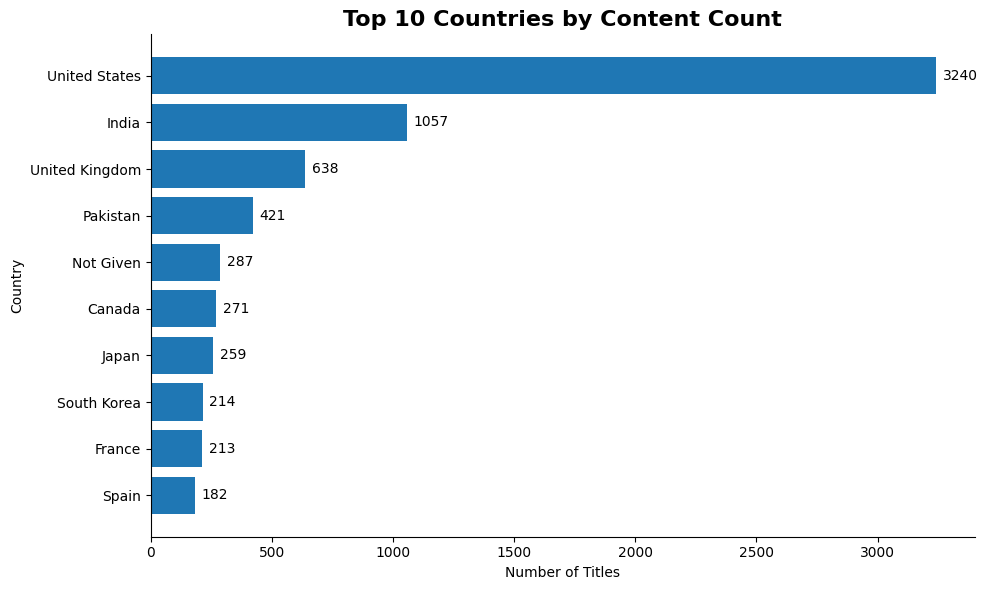

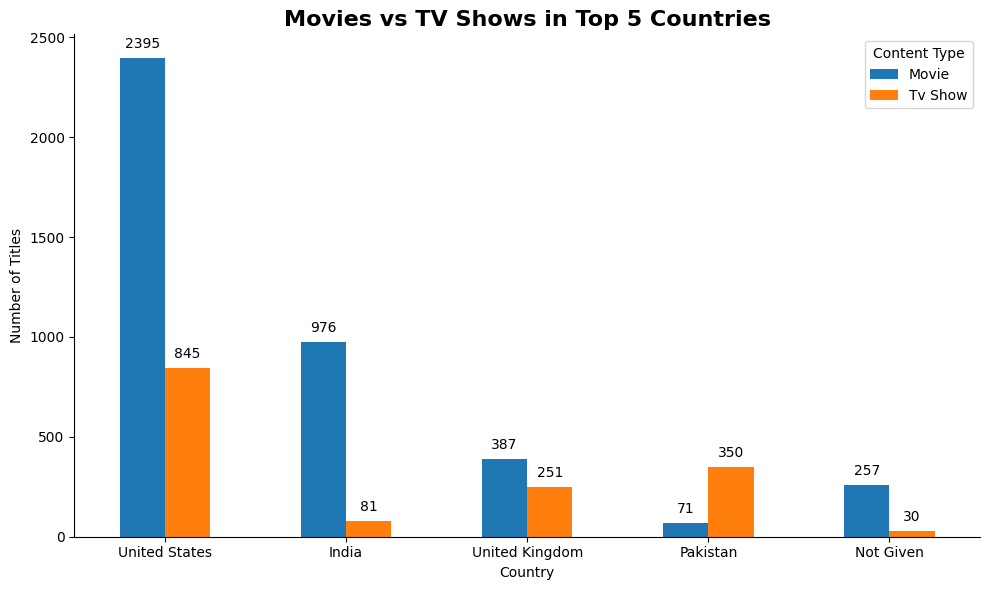

In [14]:
import matplotlib.pyplot as plt

# Chart 1: Top 10 Countries
plt.figure(figsize=(10, 6))

bars = plt.barh(top_countries["Country"],top_countries["Content Count"])
plt.title("Top 10 Countries by Content Count",fontsize=16,fontweight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.gca().invert_yaxis()
plt.bar_label(bars, fmt="%d", padding=5)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print('\n')
# Chart 2: Movies vs TV Shows

# Count Movies and TV Shows for each country
country_type_count = (df.groupby(["country", "type"]).size().unstack(fill_value=0))

# top 5 countries by total content
top_5_countries = (country_type_count.sum(axis=1).sort_values(ascending=False).head(5).index)

# Get Movie and TV Show counts for the top 5 countries
top_5_type_count = country_type_count.loc[top_5_countries]

# Create grouped bar chart
ax = top_5_type_count.plot(kind="bar",figsize=(10, 6))

plt.title("Movies vs TV Shows in Top 5 Countries",fontsize=16,fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.legend(title="Content Type")

# Add exact values above each bar
for container in ax.containers:ax.bar_label(container, fmt="%d", padding=5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Key Findings

- The United States has the highest number of titles with 3,240, followed by India with 1,057.
- Movies are more common than TV Shows in most of the top countries.
- The United States has 2,395 Movies and 845 TV Shows, showing a strong Movie presence.
- India has a much higher number of Movies (976) than TV Shows (81).
- Pakistan is the exception, with more TV Shows (350) than Movies (71).
- The United Kingdom has a relatively balanced distribution, with 387 Movies and 251 TV Shows.